# Hotel Recommendation System

A Python-based recommendation engine that suggests similar hotels by analyzing location, room types, and bed configurations. The system uses weighted features and cosine similarity to help users find the most relevant stays based on their preferences.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer


df = pd.read_csv("Hotel_Dataset.csv")

# Check the first 5 rows of the dataset
df.head()

,Hotel Name,Location,Rating,Review Score,Number of Reviews,Room Score,Room Type,Bed Type,Room Price(THB)
0,Krabi La Playa Resort - SHA Plus,Ao Nang Beach,8.2,Very Good,141,8.6,Deluxe Double or Twin Room,1 double or 2 twins,1314
1,KC Beach Club & Pool Villas,"Chaweng City Center , Chaweng",7.1,Good,193,9.0,Double Room with Balcony and Sea View,1 queen bed,1938
2,Rawai VIP Villas & Kids Park,Rawai Beach,8.3,Very Good,63,8.9,2 Bedroom Pool Villa,2 queen beds,3918
3,"FuramaXclusive Sathorn, Bangkok","Bang Rak, Bangkok",7.7,Good,1304,8.1,Executive Double Room,1 full bed,1316
4,Bo Phut Resort and Spa - SHA Plus,Bophut,9.3,Wonderful,294,9.6,Villa with Garden View,1 double or 2 twins,5590


In [2]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3465 entries, 0 to 3464
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hotel Name         3465 non-null   object 
 1   Location           3465 non-null   object 
 2   Rating             3465 non-null   float64
 3   Review Score       3359 non-null   object 
 4   Number of Reviews  3465 non-null   int64  
 5   Room Score         3465 non-null   float64
 6   Room Type          3465 non-null   object 
 7   Bed Type           3465 non-null   object 
 8   Room Price(THB)    3465 non-null   int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 243.8+ KB


### Data Cleaning & Pre-processing

In [3]:
# Detect missing values
print(df.isnull().sum())

Hotel Name             0
Location               0
Rating                 0
Review Score         106
Number of Reviews      0
Room Score             0
Room Type              0
Bed Type               0
Room Price(THB)        0
dtype: int64


In [4]:
# Find the most frequent value by mode in the 'Review Score' column
most_frequent=df['Review Score'].mode()[0]

# Fill missing values with the most frequent value
df['Review Score']=df['Review Score'].fillna(most_frequent)

print("Most common review score:", most_frequent)
print("------------------------------------")
print(df.isnull().sum())
print("------------------------------------")
print(df.describe())

Most common review score: Very Good
------------------------------------
Hotel Name           0
Location             0
Rating               0
Review Score         0
Number of Reviews    0
Room Score           0
Room Type            0
Bed Type             0
Room Price(THB)      0
dtype: int64
------------------------------------
            Rating  Number of Reviews   Room Score  Room Price(THB)
count  3465.000000        3465.000000  3465.000000      3465.000000
mean      8.202280        1022.141126     8.827792      3093.360750
std       0.800049        1341.871253     0.427401      6739.412915
min       1.000000           1.000000     8.000000        23.000000
25%       7.900000         186.000000     8.500000      1354.000000
50%       8.300000         545.000000     9.000000      2040.000000
75%       8.700000        1382.000000     9.000000      3203.000000
max      10.000000       13504.000000    10.000000    219288.000000


## Exploratory Data Analysis

### Distribution of Hotel Ratings
This chart shows the range of all rating scores in the dataset. Most ratings are between 8.0 and 9.0, showing that guests are satisfied with these hotels.

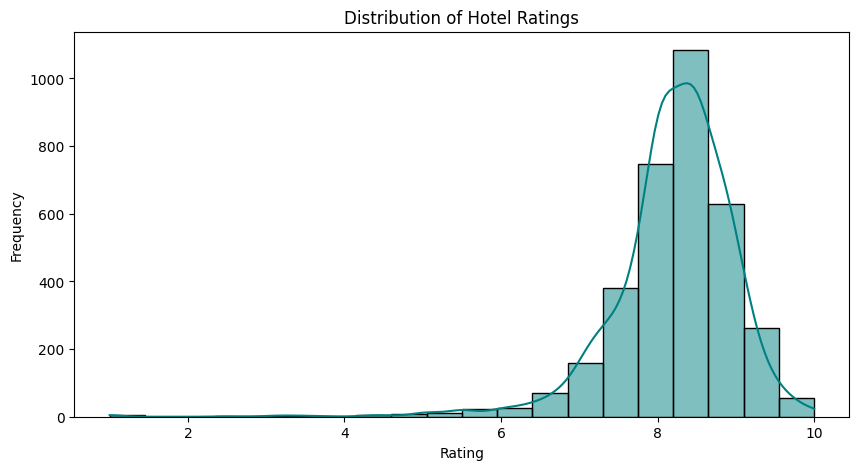

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='teal')
plt.title('Distribution of Hotel Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

### Price and Rating Relationship

Using the IQR method to remove outliers supports a more accurate  view of typical pricing.

The scatter plot shows a weak correlation between price and rating, with 7.5–9.0 ratings across all ranges, especially 1,000–4,000 THB.

Value for money important more than price alone, supporting recommendations for any budget.

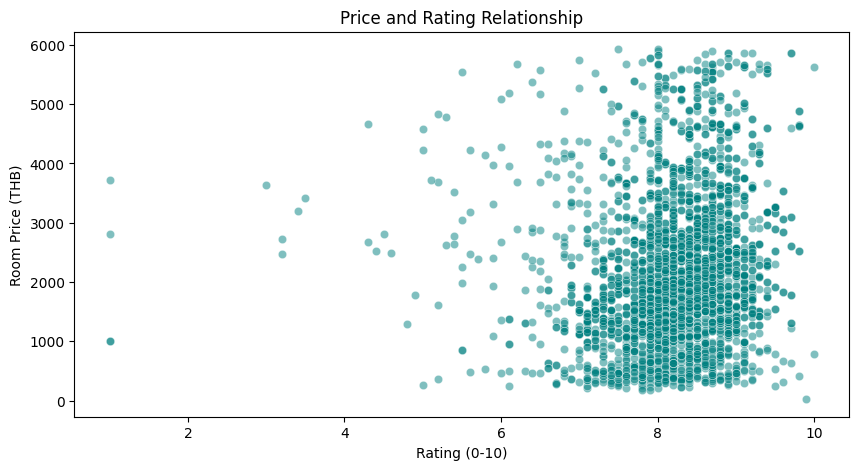

In [6]:
# Calculate the Q1 and Q3 quartiles
Q1 = df['Room Price(THB)'].quantile(0.25)
Q3 = df['Room Price(THB)'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds to remove outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data to remove outliers
df_clean = df[(df['Room Price(THB)'] >= lower_bound) &(df['Room Price(THB)'] <= upper_bound)]

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean,x='Rating',y='Room Price(THB)',color='teal',alpha=0.5)
plt.title('Price and Rating Relationship')
plt.xlabel('Rating (0-10)')
plt.ylabel('Room Price (THB)')
plt.show()


### Top 10 Locations by Hotel Count

This chart identifies the top 10 locations with the highest number of hotels, highlighting the most popular tourist areas.

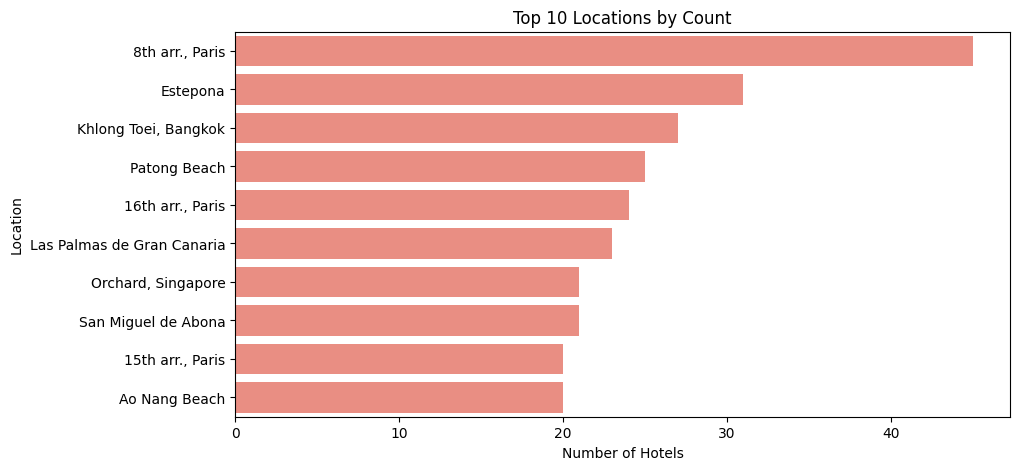

In [7]:
plt.figure(figsize=(10, 5))
top10_locations=df['Location'].value_counts().head(10)
sns.barplot(x=top10_locations.values, y=top10_locations.index, color='salmon')
plt.title('Top 10 Locations by Count')
plt.xlabel('Number of Hotels')
plt.show()

### Top 10 Locations with Highest Average Room Price

This chart highlights the top 10 locations with the highest average room prices. It supports the system in effectively matching hotel quality with the right price for each user.

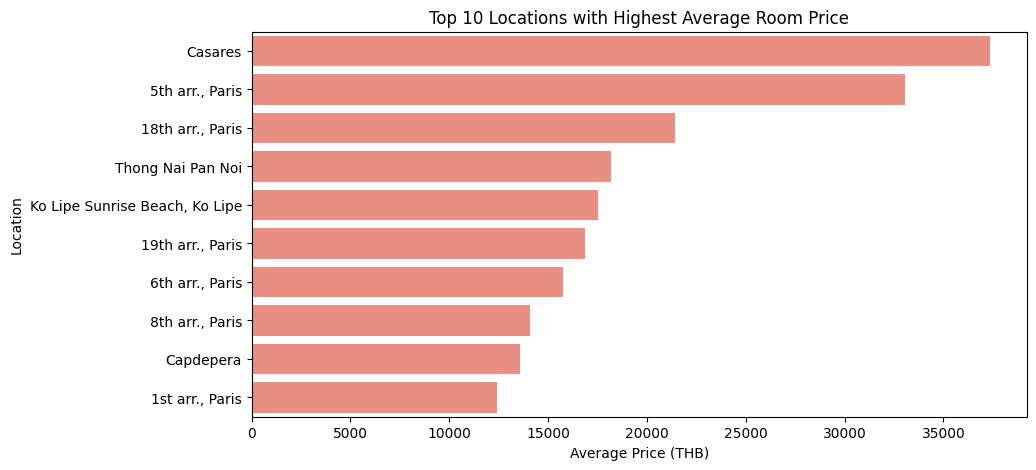

In [8]:
plt.figure(figsize=(10, 5))
top10_price=(df.groupby('Location')['Room Price(THB)'].mean().sort_values(ascending=False).head(10))
sns.barplot(x=top10_price.values, y=top10_price.index, color='salmon')
plt.title('Top 10 Locations with Highest Average Room Price')
plt.xlabel('Average Price (THB)')
plt.ylabel('Location')
plt.show()

### Recommendation Engine Building
This process creates a combined_features string by joining the Location, Room Type, and Bed Type. This string is used to calculate the similarity score of these three columns.

* The Location is repeated five times to give it more weight, because nearness is the most important factor in a hotel search, so the recommendation engine focuses more on nearby hotels.
* All text is converted to lowercase and spaces are removed to improve matching between similar hotels.


In [9]:
# Selecting key attributes for comparison
features = ['Location', 'Room Type', 'Bed Type']

# Standardizing text data to lowercase and removing spaces/commas for accurate matching
for feature in features:
    df[feature] = df[feature].fillna('').str.lower().str.replace(' ', '').str.replace(',', '')

# Combine features into a single string with weighted location
def combine_features(row):
    # Weight location to prioritize proximity
    return (row['Location'] + " ") * 5 + row['Room Type'] + " " + row['Bed Type']

df['combined_features'] = df.apply(combine_features, axis=1)

print("Sample of consolidated features (First 5 rows):")
print(df[['Hotel Name', 'combined_features']].head(5))

Sample of consolidated features (First 5 rows):
                          Hotel Name  \
0   Krabi La Playa Resort - SHA Plus   
1        KC Beach Club & Pool Villas   
2       Rawai VIP Villas & Kids Park   
3    FuramaXclusive Sathorn, Bangkok   
4  Bo Phut Resort and Spa - SHA Plus   

                                   combined_features  
0  aonangbeach aonangbeach aonangbeach aonangbeac...  
1  chawengcitycenterchaweng chawengcitycenterchaw...  
2  rawaibeach rawaibeach rawaibeach rawaibeach ra...  
3  bangrakbangkok bangrakbangkok bangrakbangkok b...  
4  bophut bophut bophut bophut bophut villawithga...  


### Text Vectorization and Similarity Measurement

This process converts the cleaned text into numbers using CountVectorizer, creating a feature table of word counts. Then Cosine Similarity is applied to measure how similar each hotel is to others, forming the core of the system for finding and ranking the most similar hotels.

In [10]:
# Transforming text descriptions into a numerical matrix
cv = CountVectorizer()
count_matrix = cv.fit_transform(df['combined_features'])

# Calculating the similarity scores between all hotel pairs
similarity = cosine_similarity(count_matrix)

print(f"Numerical Matrix Size: {count_matrix.shape}")

Numerical Matrix Size: (3465, 2062)


### Recommendation Retrieval

This process is used to find the hotels most similar to any given property. This is where the model is applied in practice, allowing the system to provide personalized results to users.

In [11]:
# Check hotel names containing 'Phuket'
search_keyword = 'phuket'
find_hotel = df[df['Hotel Name'].str.contains(search_keyword, case=False, na=False)]

print("Hotels found:")
print(find_hotel['Hotel Name'].head())

Hotels found:
12         Waterfront Suites Phuket by Centara
18    The Blanket Hotel Phuket Town - SHA Plus
28    I Pavilion Hotel Phuket - SHA Extra Plus
46         Marina House MUAYTHAI Ta-iad Phuket
71                       Phuket Beach Glamping
Name: Hotel Name, dtype: object


In [12]:
def get_recommendations(hotel_name, df, similarity_matrix, limit=5):
    # Get index of the target hotel
    idx = df[df['Hotel Name'].str.contains(hotel_name, case=False)].index[0]
    
    # Get and sort similarity scores
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Sort by similarity scores in descending order (excluding the target hotel itself)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:limit+1]
    
    # Extract indices and scores
    hotel_idx= [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores] 
    
    # Create result DataFrame and add sim_score column
    rec_sim = df.iloc[hotel_idx][['Hotel Name', 'Location', 'Rating']].copy()
    rec_sim['sim_score'] = scores
    
    print(f"Searching recommendations for: {df.iloc[idx]['Hotel Name']}")
    return rec_sim

### Testing the Recommendation System
Finally, this process runs the recommendation function to test the system by inputting a specific hotel name or keyword, retrieving the top 5 most similar results based on the calculated similarity scores.

In [13]:
rec = get_recommendations('indigo phuket', df, similarity, limit=5)
print(rec)

Searching recommendations for: Hotel Indigo Phuket Patong, an IHG Hotel - SHA Extra Plus
                                            Hotel Name     Location  Rating  \
265  Holiday Inn Express Phuket Patong Beach Centra...  patongbeach     8.0   
306                   Zenseana Resort & Spa - SHA Plus  patongbeach     8.0   
587      Tropica Bungalow Beach Hotel - SHA Extra Plus  patongbeach     7.9   
649    The Royal Paradise Hotel & Spa - SHA Extra Plus  patongbeach     7.8   
34                           Armoni Patong Beach Hotel  patongbeach     7.4   

     sim_score  
265   0.962963  
306   0.962963  
587   0.962963  
649   0.945611  
34    0.925926  


### Conclusion
The system is used to find hotels that share similar features using content-based filtering. The main value of this project is that it automates the hotel discovery process for users. Future improvements could include adding user-based collaborative filtering or more detailed features, such as hotel amenities and real-time availability.